In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')



In [2]:
df = pd.read_csv("D:/DLM Research/processed_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55883 entries, 0 to 55882
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   patient_id                          55883 non-null  float64
 1   delivery_datetime                   55857 non-null  object 
 2   fundal_height_cm                    55883 non-null  int64  
 3   maternal_age_years                  55883 non-null  float64
 4   maternal_weight_kg                  55883 non-null  float64
 5   gestational_age_weeks               55883 non-null  object 
 6   fetal_presentation                  55883 non-null  object 
 7   fetal_lie                           55883 non-null  object 
 8   placenta_status                     55883 non-null  object 
 9   maternal_outcome_status             55883 non-null  object 
 10  history_hypertension                55883 non-null  float64
 11  history_diabetes                    55883

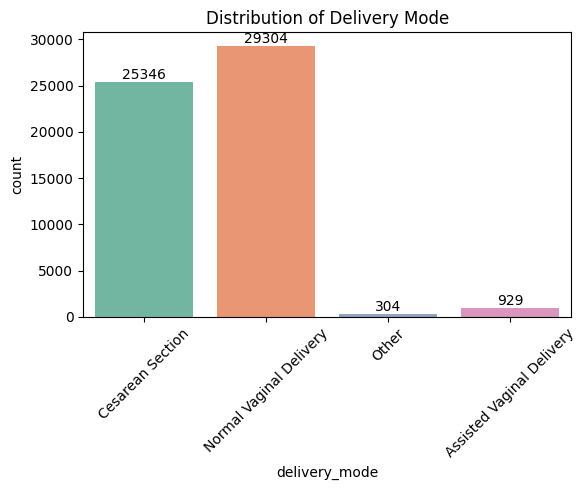

In [4]:
plt.figure(figsize=(6,5))

ax = sns.countplot(x='delivery_mode', data=df, palette='Set2')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Delivery Mode")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

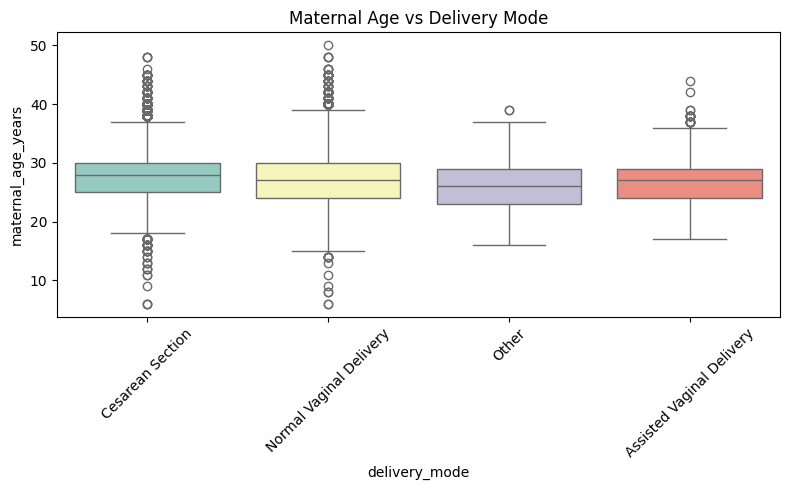

In [5]:
plt.figure(figsize=(8,5))

sns.boxplot(x='delivery_mode', y='maternal_age_years', data=df, palette='Set3')

plt.title("Maternal Age vs Delivery Mode")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

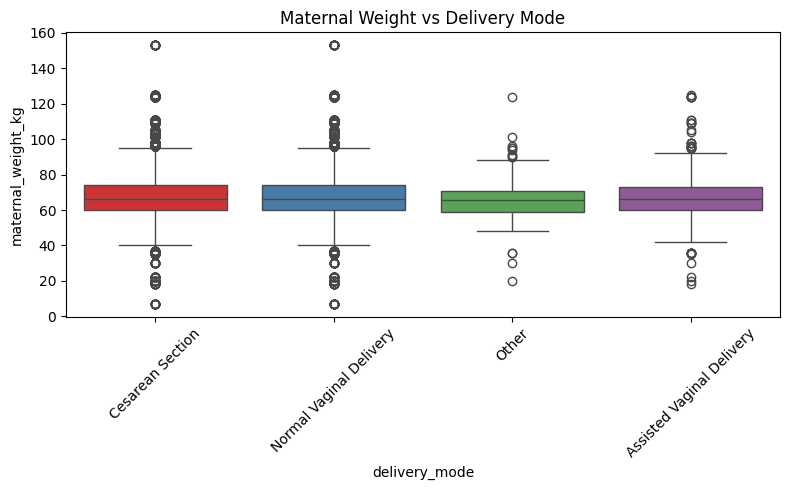

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(x='delivery_mode', y='maternal_weight_kg', data=df, palette='Set1')

plt.title("Maternal Weight vs Delivery Mode")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

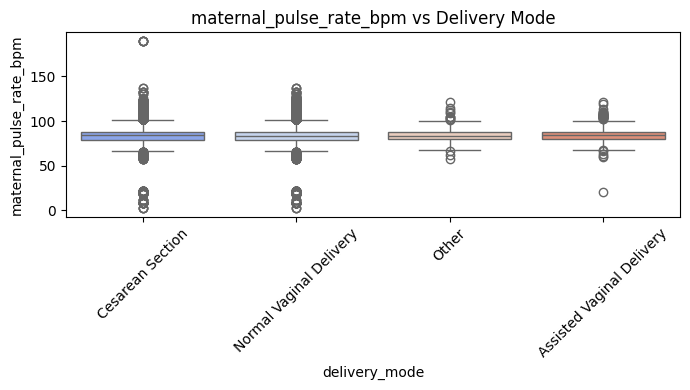

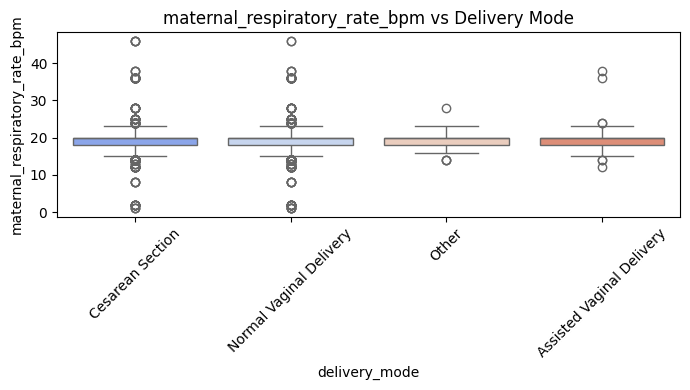

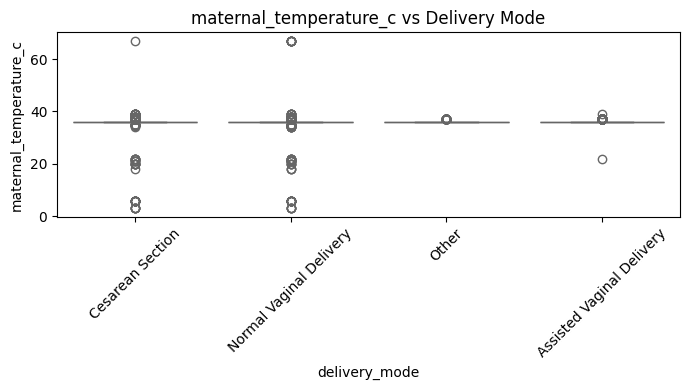

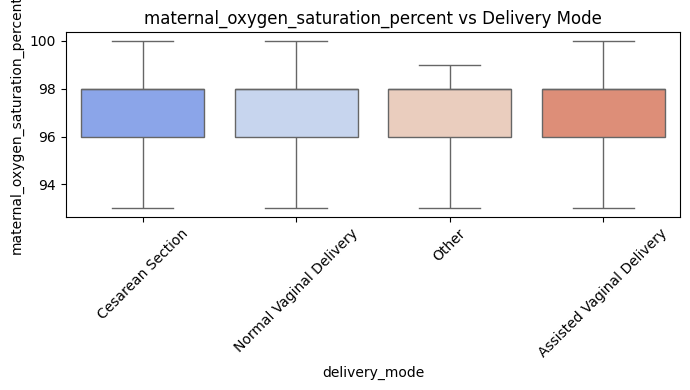

In [7]:
vitals = [
    'maternal_pulse_rate_bpm',
    'maternal_respiratory_rate_bpm',
    'maternal_temperature_c',
    'maternal_oxygen_saturation_percent'
]

for col in vitals:
    plt.figure(figsize=(7,4))
    sns.boxplot(x='delivery_mode', y=col, data=df, palette='coolwarm')
    plt.title(f"{col} vs Delivery Mode")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

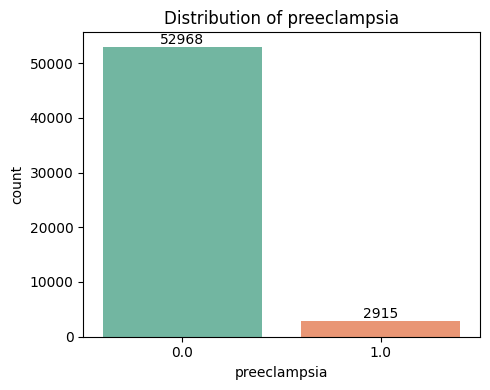

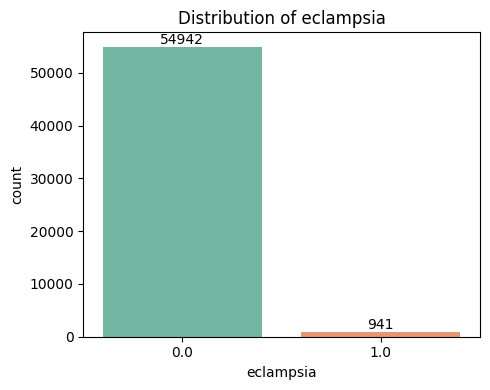

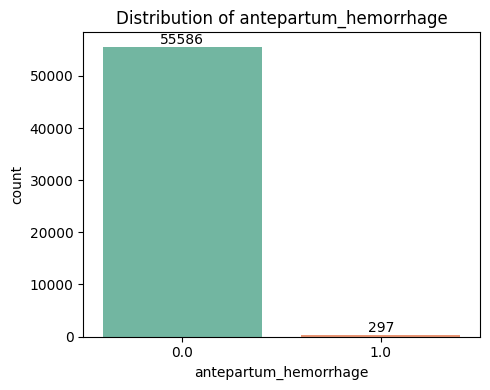

In [8]:
conditions = ['preeclampsia', 'eclampsia', 'antepartum_hemorrhage']

for col in conditions:
    plt.figure(figsize=(5,4))
    
    ax = sns.countplot(x=col, data=df, palette='Set2')
    
    for container in ax.containers:
        ax.bar_label(container)
    
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

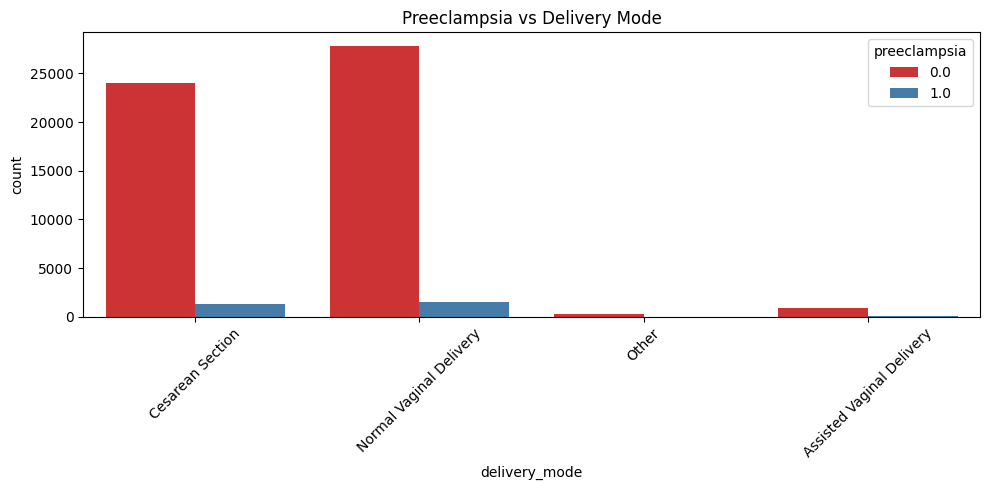

In [9]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='delivery_mode',
    hue='preeclampsia',
    data=df,
    palette='Set1'
)

plt.title("Preeclampsia vs Delivery Mode")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

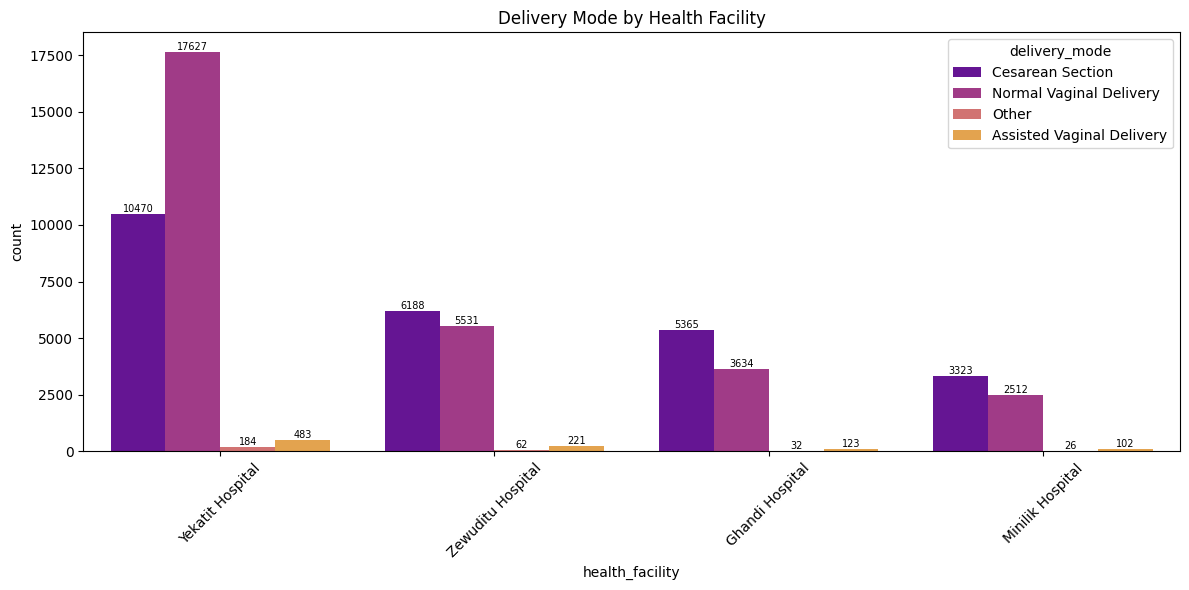

In [11]:
plt.figure(figsize=(12,6))

order = df['health_facility'].value_counts().index

ax = sns.countplot(
    x='health_facility',
    hue='delivery_mode',
    data=df,
    order=order,
    palette='plasma'
)

for container in ax.containers:
    ax.bar_label(container, fontsize=7)

plt.xticks(rotation=45)
plt.title("Delivery Mode by Health Facility")
plt.tight_layout()
plt.show()

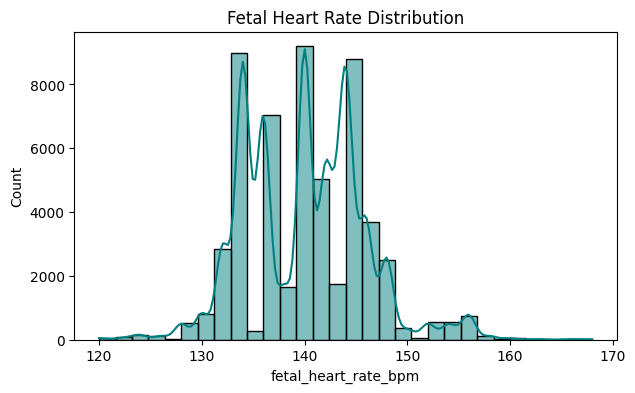

In [12]:
plt.figure(figsize=(7,4))

sns.histplot(df['fetal_heart_rate_bpm'], bins=30, kde=True, color='teal')

plt.title("Fetal Heart Rate Distribution")
plt.show()

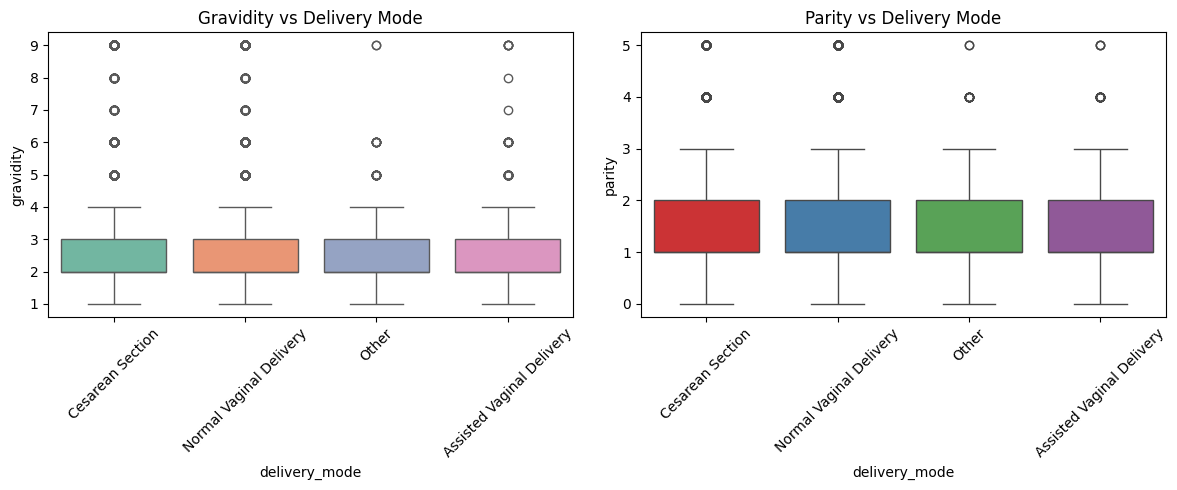

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='delivery_mode', y='gravidity', data=df, ax=axes[0], palette='Set2')
axes[0].set_title("Gravidity vs Delivery Mode")
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='delivery_mode', y='parity', data=df, ax=axes[1], palette='Set1')
axes[1].set_title("Parity vs Delivery Mode")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

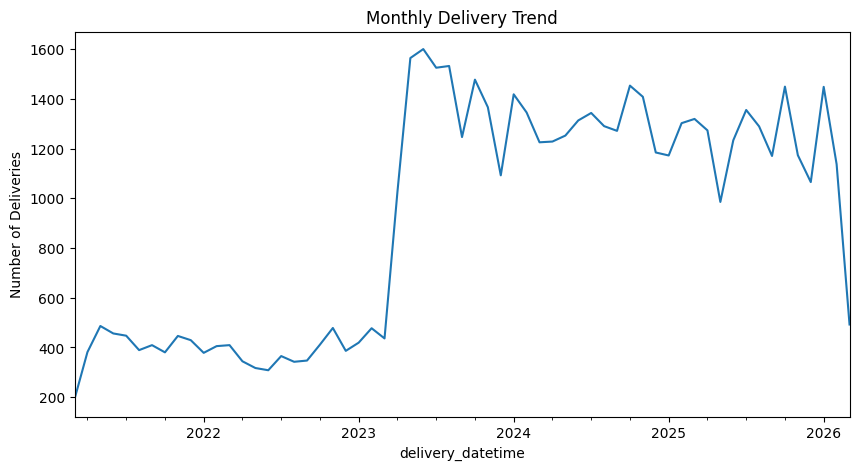

In [14]:
df['delivery_datetime'] = pd.to_datetime(df['delivery_datetime'], errors='coerce')

df.groupby(df['delivery_datetime'].dt.to_period('M')).size().plot(figsize=(10,5))

plt.title("Monthly Delivery Trend")
plt.ylabel("Number of Deliveries")
plt.show()

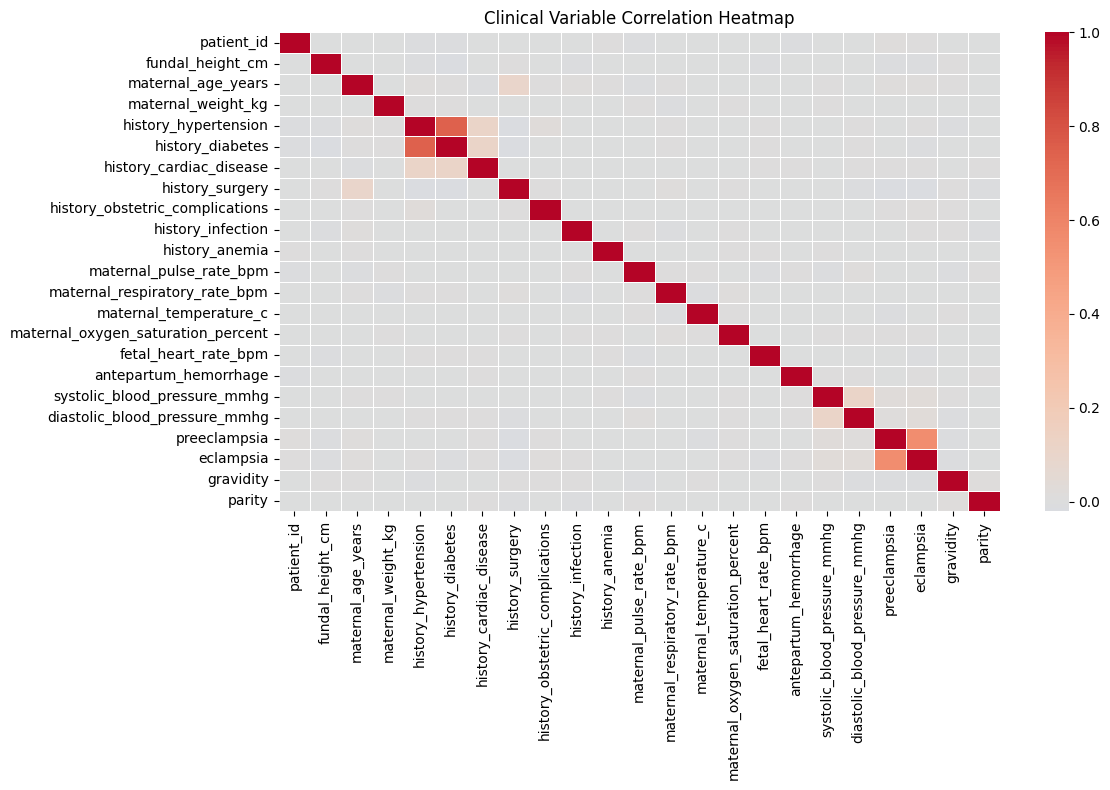

In [16]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=['float64', 'int64']).corr()

sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)

plt.title("Clinical Variable Correlation Heatmap")
plt.tight_layout()
plt.show()

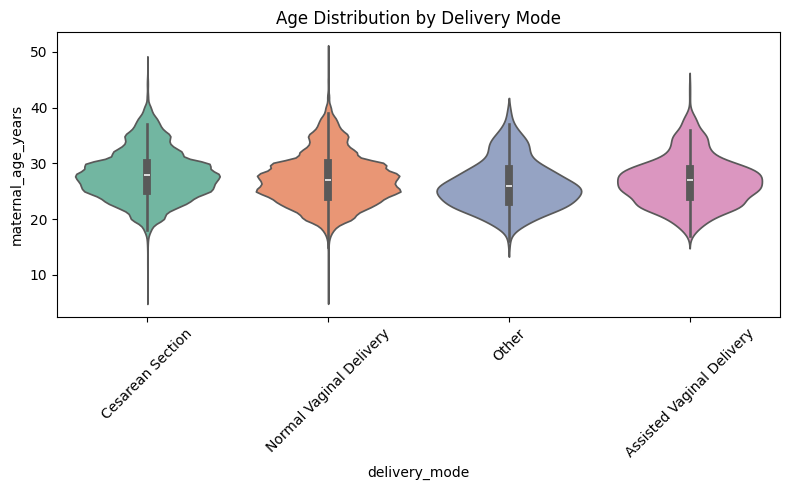

In [17]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='delivery_mode',
    y='maternal_age_years',
    data=df,
    palette='Set2'
)

plt.title("Age Distribution by Delivery Mode")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

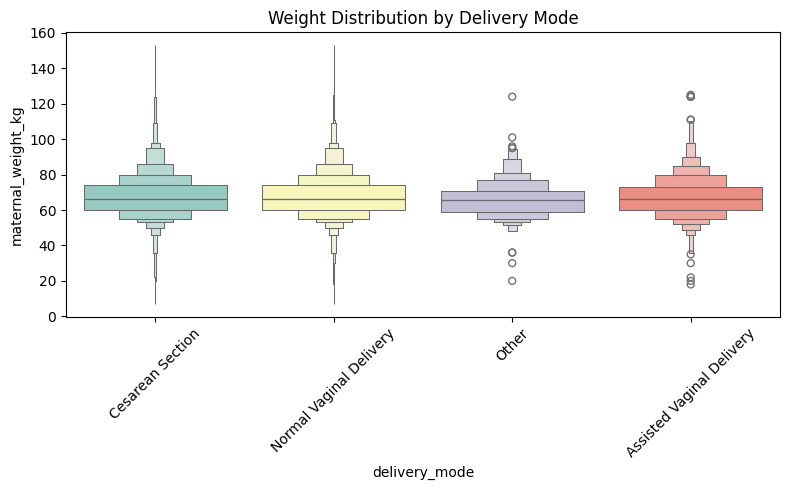

In [20]:
plt.figure(figsize=(8,5))

sns.boxenplot(
    x='delivery_mode',
    y='maternal_weight_kg',
    data=df,
    palette='Set3'
)

plt.title("Weight Distribution by Delivery Mode")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

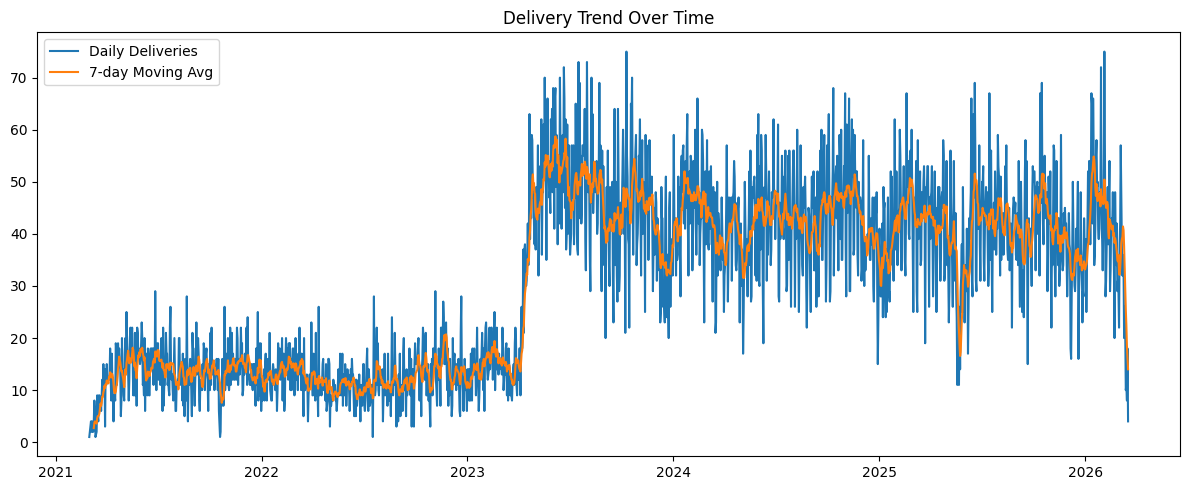

In [21]:
df['delivery_datetime'] = pd.to_datetime(df['delivery_datetime'], errors='coerce')

time_series = df.groupby(df['delivery_datetime'].dt.date).size()

rolling = time_series.rolling(7).mean()

plt.figure(figsize=(12,5))

plt.plot(time_series, label='Daily Deliveries')
plt.plot(rolling, label='7-day Moving Avg')

plt.title("Delivery Trend Over Time")
plt.legend()
plt.tight_layout()
plt.show()

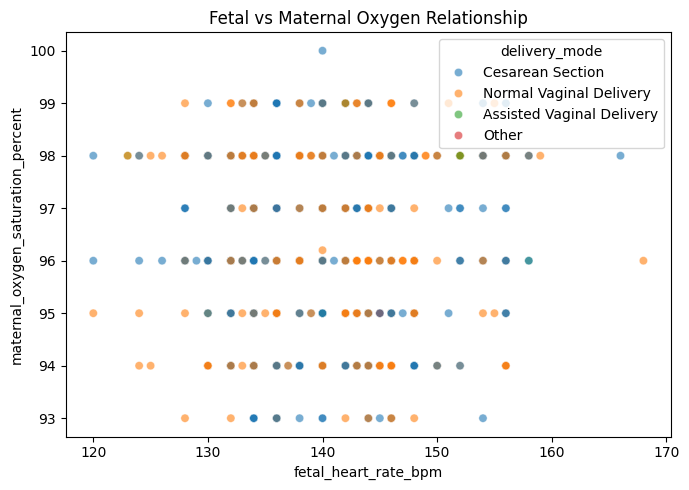

In [22]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='fetal_heart_rate_bpm',
    y='maternal_oxygen_saturation_percent',
    hue='delivery_mode',
    data=df.sample(2000),
    alpha=0.6
)

plt.title("Fetal vs Maternal Oxygen Relationship")
plt.tight_layout()
plt.show()